<a href="https://colab.research.google.com/github/ms-eea/myportfoliowebsite/blob/main/Dynamic_Enterprise_Product_Evaluation_Harness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enterprise AI Telemetry & Scorecard

## Simulating Multi-Project Telemetry

In [2]:
import pandas as pd
import numpy as np

# Define the enterprise projects
PROJECT_NAMES = [
    'Patient Chat Agent',
    'Sycophancy Audit Harness',
    'Daily Telemetry Engine',
    'EHR Context Streamer'
]

def simulate_telemetry(project_names, num_data_points=30):
    """Simulates synthetic production metrics for multiple enterprise projects."""
    data = []
    for project in project_names:
        for _ in range(num_data_points):
            data.append({
                'project': project,
                'date': pd.to_datetime(f'2023-01-01') + pd.to_timedelta(_ * 24, unit='h'),
                # Financial & Unit Economics
                'cost_per_run': np.random.uniform(0.01, 0.5), # dollars per run/token
                'annualized_cost_savings': np.random.uniform(100000, 1000000), # dollars
                'infrastructure_payback_period': np.random.uniform(3, 18), # months
                # Operational Velocity
                'dev_cycle_reduction': np.random.uniform(5, 50), # percentage
                'execution_latency_p95': np.random.uniform(50, 500), # milliseconds
                'execution_latency_p99': np.random.uniform(100, 1000), # milliseconds
                'task_completion_velocity': np.random.uniform(10, 100), # tasks per hour
                # Safety, Guardrails & Quality
                'policy_survival_rate': np.random.uniform(80, 99.9), # percentage
                'sycophantic_drift_rate': np.random.uniform(0.1, 5), # percentage
                'hallucination_rate': np.random.uniform(0.1, 10), # percentage
                'human_escalation_frequency': np.random.randint(1, 20), # per day
                # Adoption & System Health
                'api_error_rate': np.random.uniform(0.1, 2), # percentage
                'active_workflow_utilization': np.random.uniform(20, 90), # percentage
                'system_uptime': np.random.uniform(99, 99.99) # percentage
            })
    return pd.DataFrame(data)

# Generate the synthetic telemetry data
telemetry_df = simulate_telemetry(PROJECT_NAMES)

# Display the first few rows of the generated data
print("Generated synthetic telemetry data:")
display(telemetry_df.head())


Generated synthetic telemetry data:


,project,date,cost_per_run,annualized_cost_savings,infrastructure_payback_period,dev_cycle_reduction,execution_latency_p95,execution_latency_p99,task_completion_velocity,policy_survival_rate,sycophantic_drift_rate,hallucination_rate,human_escalation_frequency,api_error_rate,active_workflow_utilization,system_uptime
0,Patient Chat Agent,2023-01-01,0.053152,256565.911058,14.600338,43.961675,154.767433,533.798658,62.210167,83.769285,1.515099,4.515195,1,1.058460,62.903219,99.070108
1,Patient Chat Agent,2023-01-02,0.252551,426746.649782,12.687868,35.337836,52.895093,976.549152,32.916112,93.242322,3.230715,1.938675,18,0.602500,81.890414,99.851147
2,Patient Chat Agent,2023-01-03,0.443495,298976.195977,17.095857,44.194309,480.024748,696.952682,94.874922,90.621790,1.737585,7.141731,16,0.188263,84.005920,99.850021
3,Patient Chat Agent,2023-01-04,0.086181,797525.637079,17.409365,14.527152,322.062208,776.201215,74.699981,95.016032,2.966553,7.343505,5,1.343581,21.496415,99.809154
4,Patient Chat Agent,2023-01-05,0.103072,565244.845499,3.902510,8.657183,187.453410,393.383760,23.910973,86.185685,1.124287,0.912994,12,0.142665,77.449533,99.507346


## Compute Normalized Performance Index (NPI)

In [4]:
# Define NPI weights and scoring logic
def calculate_npi(df):
    # Helper function to normalize metrics
    def normalize_score(series, higher_is_better=True):
        min_val = series.min()
        max_val = series.max()
        if max_val == min_val:
            # If all values are the same, assign a perfect score (100) as there's no room for improvement/degradation
            return pd.Series(100.0, index=series.index)
        elif higher_is_better:
            return ((series - min_val) / (max_val - min_val) * 100).fillna(0)
        else:
            return ((max_val - series) / (max_val - min_val) * 100).fillna(0)

    # ROI Component: Higher cost savings, lower cost per run, shorter payback period are better
    df['roi_score'] = normalize_score(df['annualized_cost_savings'], higher_is_better=True)
    df['cost_per_run_score'] = normalize_score(df['cost_per_run'], higher_is_better=False)
    df['payback_period_score'] = normalize_score(df['infrastructure_payback_period'], higher_is_better=False)

    df['combined_roi'] = (df['roi_score'] * 0.5 + df['cost_per_run_score'] * 0.3 + df['payback_period_score'] * 0.2).clip(0, 100)

    # Safety Component: Higher policy survival, lower drift/hallucination, lower escalation are better
    # policy_survival_rate is already 0-100, so we can use it directly as a score or normalize if needed.
    # For consistency, let's treat it as a score directly.
    df['policy_survival_score'] = df['policy_survival_rate'].clip(0,100)
    df['sycophantic_drift_score'] = normalize_score(df['sycophantic_drift_rate'], higher_is_better=False)
    df['hallucination_score'] = normalize_score(df['hallucination_rate'], higher_is_better=False)
    df['human_escalation_score'] = normalize_score(df['human_escalation_frequency'], higher_is_better=False)

    df['combined_safety'] = (df['policy_survival_score'] * 0.4 + df['sycophantic_drift_score'] * 0.3 +
                             df['hallucination_score'] * 0.2 + df['human_escalation_score'] * 0.1).clip(0, 100)

    # Latency Component: Lower execution latency is better
    df['latency_p95_score'] = normalize_score(df['execution_latency_p95'], higher_is_better=False)
    df['latency_p99_score'] = normalize_score(df['execution_latency_p99'], higher_is_better=False)

    df['combined_latency'] = (df['latency_p95_score'] * 0.6 + df['latency_p99_score'] * 0.4).clip(0, 100)

    # NPI Calculation with weights (adjust as needed)
    # Example weights: ROI (40%), Safety (40%), Latency (20%)
    df['NPI'] = (df['combined_roi'] * 0.4 + df['combined_safety'] * 0.4 + df['combined_latency'] * 0.2).clip(0, 100)

    return df

telemetry_df = telemetry_df.groupby('project', group_keys=False).apply(calculate_npi).reset_index(drop=True)

print("Telemetry data with NPI:")
display(telemetry_df[['project', 'date', 'NPI', 'combined_roi', 'combined_safety', 'combined_latency']].head())

Telemetry data with NPI:


/tmp/ipykernel_1236/3063948044.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  telemetry_df = telemetry_df.groupby('project', group_keys=False).apply(calculate_npi).reset_index(drop=True)


,project,date,NPI,combined_roi,combined_safety,combined_latency
0,Daily Telemetry Engine,2023-01-01,49.885118,48.519698,71.932978,8.520241
1,Daily Telemetry Engine,2023-01-02,46.777489,29.183833,69.108527,37.302725
2,Daily Telemetry Engine,2023-01-03,66.292771,43.428282,82.828380,78.950534
3,Daily Telemetry Engine,2023-01-04,40.801197,9.976051,73.680437,36.693009
4,Daily Telemetry Engine,2023-01-05,70.919732,49.175471,84.203223,87.841272


## Generate Executive Scorecard Dataframe

In [5]:
# Aggregate telemetry_df to get average NPI and other key metrics per project
scorecard_df = telemetry_df.groupby('project').agg(
    NPI=('NPI', 'mean'),
    ROI_Score=('combined_roi', 'mean'),
    Safety_Score=('combined_safety', 'mean'),
    Latency_Score=('combined_latency', 'mean'),
    Cost_per_Run=('cost_per_run', 'mean'),
    Policy_Survival_Rate=('policy_survival_rate', 'mean'),
    Execution_Latency_p95=('execution_latency_p95', 'mean'),
    System_Uptime=('system_uptime', 'mean')
).reset_index()

# Round relevant columns for better readability
scorecard_df = scorecard_df.round({
    'NPI': 2,
    'ROI_Score': 2,
    'Safety_Score': 2,
    'Latency_Score': 2,
    'Cost_per_Run': 3,
    'Policy_Survival_Rate': 2,
    'Execution_Latency_p95': 2,
    'System_Uptime': 2
})

# Define conditional formatting function
def color_scorecard(val, metric_name):
    green_threshold_npi = 80
    amber_threshold_npi = 60

    green_threshold_roi = 70 # Higher ROI is better
    amber_threshold_roi = 50

    green_threshold_safety = 85 # Higher Safety is better
    amber_threshold_safety = 70

    green_threshold_latency = 70 # Higher Latency Score (lower actual latency) is better
    amber_threshold_latency = 50

    green_threshold_cost_per_run = 0.1 # Lower cost per run is better
    amber_threshold_cost_per_run = 0.3

    green_threshold_policy = 95 # Higher policy survival is better
    amber_threshold_policy = 90

    green_threshold_uptime = 99.9 # Higher uptime is better
    amber_threshold_uptime = 99.5

    color = ''
    if metric_name == 'NPI':
        if val >= green_threshold_npi:
            color = 'background-color: #e6ffe6' # Light Green
        elif val >= amber_threshold_npi:
            color = 'background-color: #fffacd' # Light Yellow
        else:
            color = 'background-color: #ffe6e6' # Light Red
    elif metric_name == 'ROI_Score':
        if val >= green_threshold_roi:
            color = 'background-color: #e6ffe6'
        elif val >= amber_threshold_roi:
            color = 'background-color: #fffacd'
        else:
            color = 'background-color: #ffe6e6'
    elif metric_name == 'Safety_Score':
        if val >= green_threshold_safety:
            color = 'background-color: #e6ffe6'
        elif val >= amber_threshold_safety:
            color = 'background-color: #fffacd'
        else:
            color = 'background-color: #ffe6e6'
    elif metric_name == 'Latency_Score':
        if val >= green_threshold_latency:
            color = 'background-color: #e6ffe6'
        elif val >= amber_threshold_latency:
            color = 'background-color: #fffacd'
        else:
            color = 'background-color: #ffe6e6'
    elif metric_name == 'Cost_per_Run':
        if val <= green_threshold_cost_per_run:
            color = 'background-color: #e6ffe6'
        elif val <= amber_threshold_cost_per_run:
            color = 'background-color: #fffacd'
        else:
            color = 'background-color: #ffe6e6'
    elif metric_name == 'Policy_Survival_Rate':
        if val >= green_threshold_policy:
            color = 'background-color: #e6ffe6'
        elif val >= amber_threshold_policy:
            color = 'background-color: #fffacd'
        else:
            color = 'background-color: #ffe6e6'
    elif metric_name == 'System_Uptime':
        if val >= green_threshold_uptime:
            color = 'background-color: #e6ffe6'
        elif val >= amber_threshold_uptime:
            color = 'background-color: #fffacd'
        else:
            color = 'background-color: #ffe6e6'
    # Add other metrics as needed
    return color

# Apply conditional formatting
styler = scorecard_df.style
for col in ['NPI', 'ROI_Score', 'Safety_Score', 'Latency_Score', 'Cost_per_Run', 'Policy_Survival_Rate', 'System_Uptime']:
    styler = styler.apply(lambda x: x.apply(lambda y: color_scorecard(y, col)), subset=[col])

print("Executive Scorecard:")
display(styler)

Executive Scorecard:


,project,NPI,ROI_Score,Safety_Score,Latency_Score,Cost_per_Run,Policy_Survival_Rate,Execution_Latency_p95,System_Uptime
0,Daily Telemetry Engine,58.190000,50.200000,69.040000,52.460000,0.209000,89.460000,256.810000,99.580000
1,EHR Context Streamer,55.900000,50.990000,67.730000,42.060000,0.277000,90.300000,311.550000,99.640000
2,Patient Chat Agent,55.260000,50.710000,64.110000,46.640000,0.231000,88.360000,272.150000,99.540000
3,Sycophancy Audit Harness,53.550000,43.600000,67.090000,46.350000,0.309000,88.210000,265.250000,99.530000


## Export Visual Analytics

Generating Radar Charts...


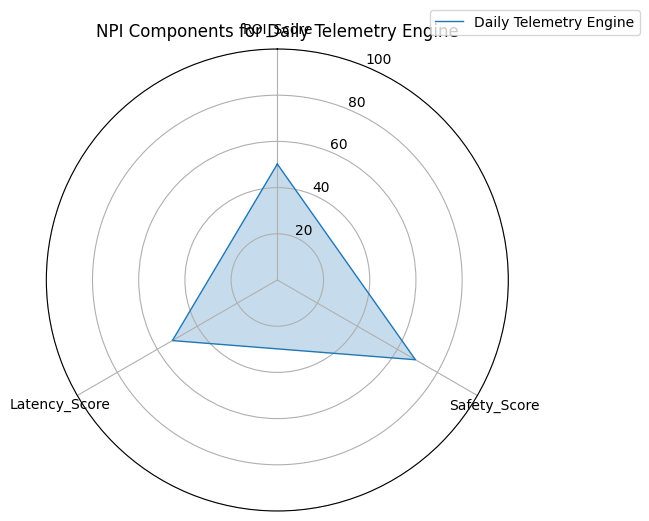

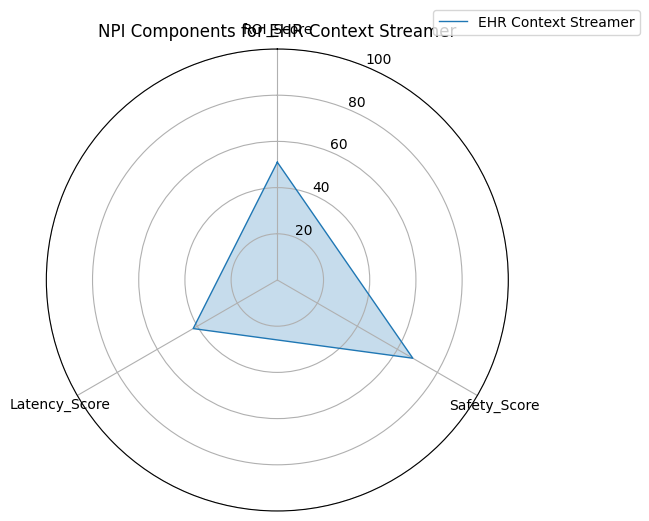

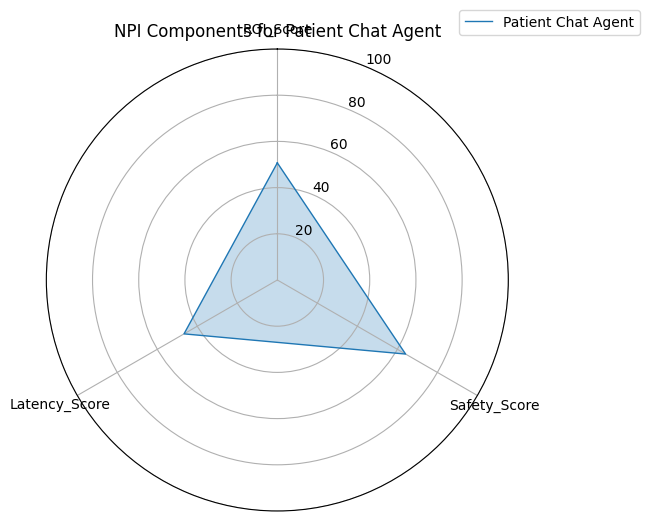

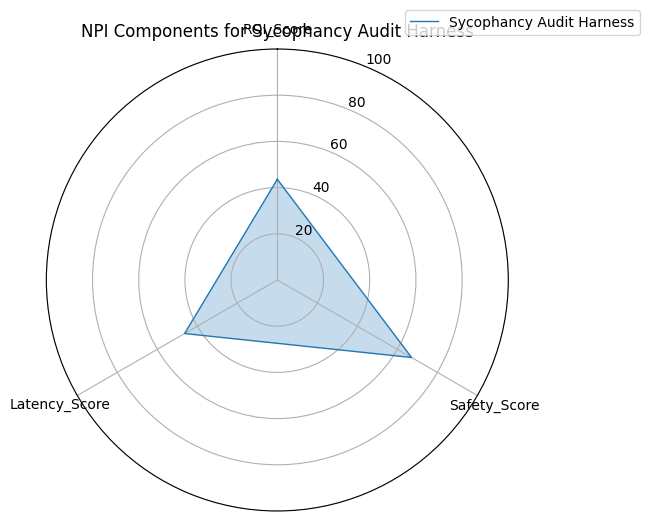

Generating Cost vs. Safety Tradeoff Scatter Plot...


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- Radar Charts for NPI Components ---
print("Generating Radar Charts...")

def create_radar_chart(df, title, categories, value_col, project_name):
    # Number of variables we're plotting.
    num_vars = len(categories)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    # Complete the loop
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    values = df[value_col].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=project_name)
    ax.fill(angles, values, alpha=0.25)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    ax.set_ylim(0, 100) # NPI components are 0-100
    ax.set_title(title, va='bottom')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    return fig


npi_components = ['ROI_Score', 'Safety_Score', 'Latency_Score']

for project in scorecard_df['project'].unique():
    project_data = scorecard_df[scorecard_df['project'] == project]
    if not project_data.empty:
        # Get the original index value of the project_data row to use for renaming
        original_index_col_name = project_data.index[0]
        fig = create_radar_chart(
            project_data[npi_components].transpose().reset_index().rename(columns={'index': 'category', original_index_col_name: 'value'}),
            f'NPI Components for {project}',
            npi_components,
            'value',
            project # Pass the project name directly
        )
        plt.show()

# --- Cost vs. Safety Tradeoff Scatter Plot ---
print("Generating Cost vs. Safety Tradeoff Scatter Plot...")

fig = px.scatter(
    scorecard_df,
    x='Cost_per_Run',
    y='Safety_Score',
    color='project',
    size='NPI', # Size points by overall NPI
    hover_name='project',
    title='Cost-per-Run vs. Safety Score Tradeoff',
    labels={'Cost_per_Run': 'Average Cost per Run ($)', 'Safety_Score': 'Average Safety Score (0-100)'}
)
fig.update_layout(xaxis_title='Average Cost per Run (Lower is Better)',
                  yaxis_title='Average Safety Score (Higher is Better)',
                  yaxis_range=[0, 100]) # Safety score is 0-100
fig.show()


## Performance Trends Over Time

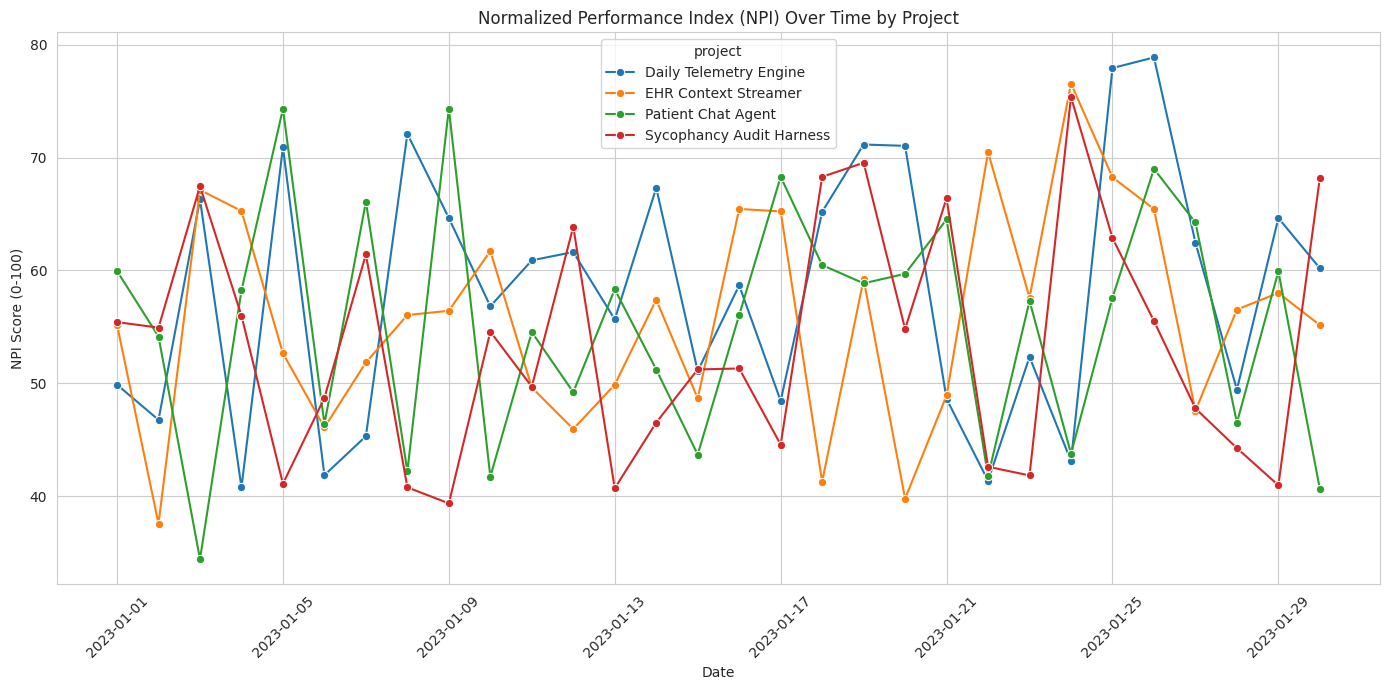

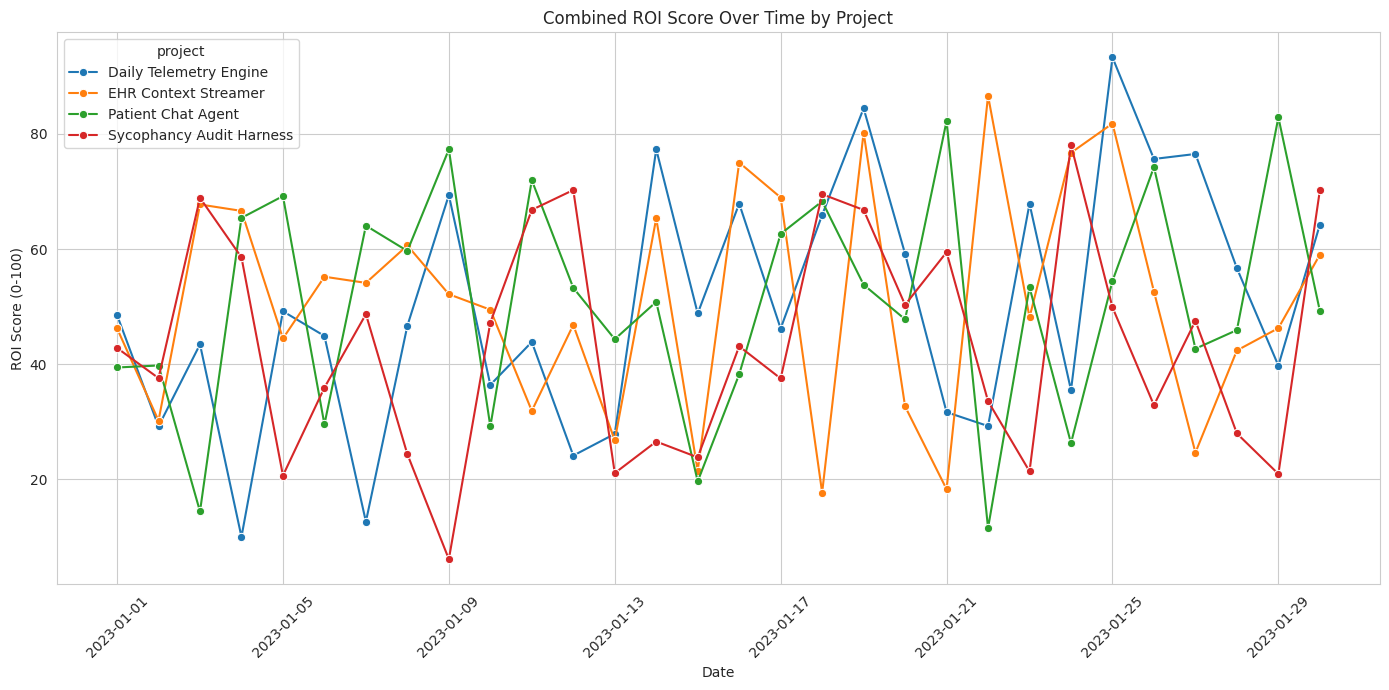

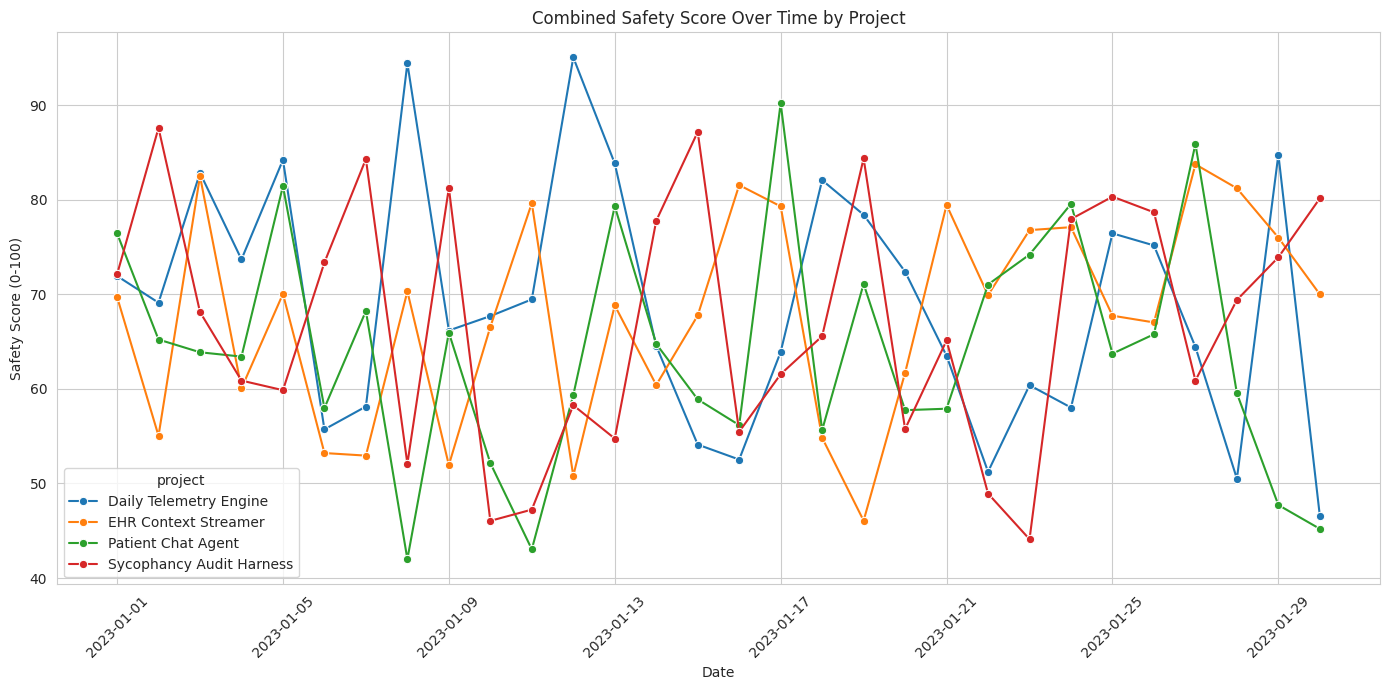

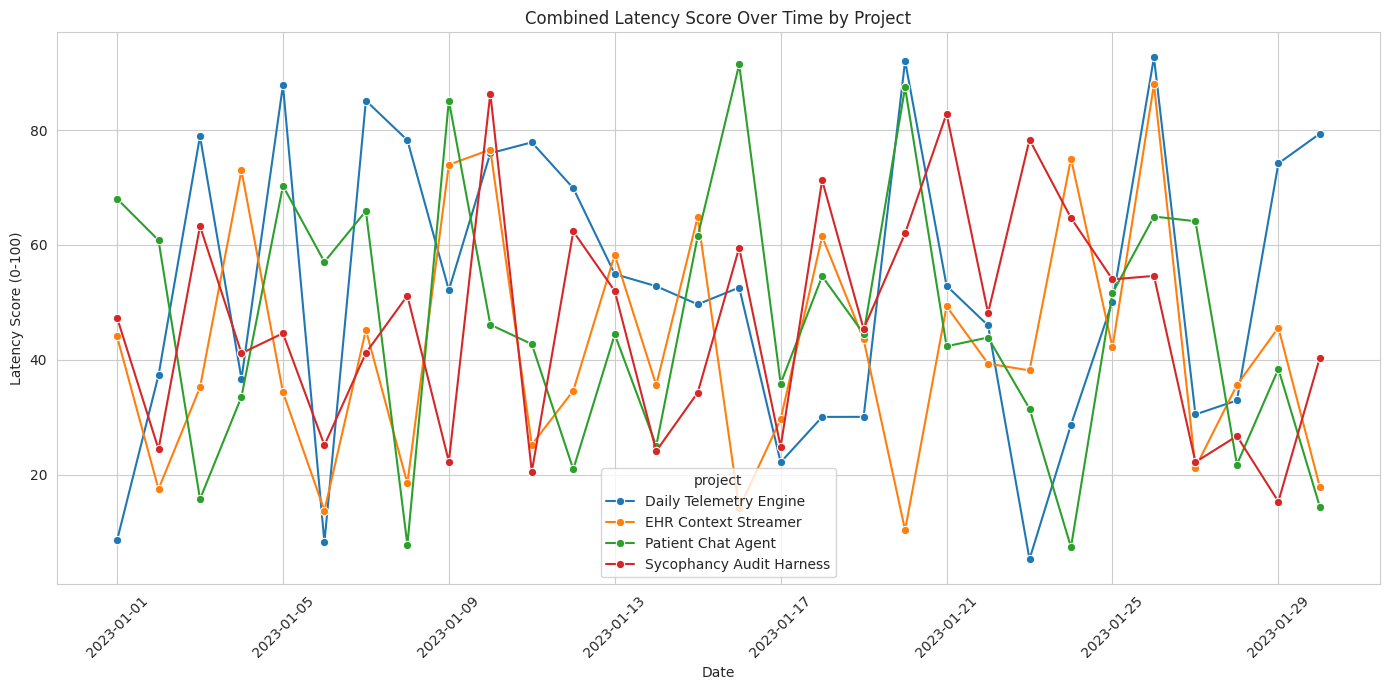

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# --- Plot NPI over time for each project ---
plt.figure(figsize=(14, 7))
sns.lineplot(data=telemetry_df, x='date', y='NPI', hue='project', marker='o')
plt.title('Normalized Performance Index (NPI) Over Time by Project')
plt.xlabel('Date')
plt.ylabel('NPI Score (0-100)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot ROI Score over time for each project ---
plt.figure(figsize=(14, 7))
sns.lineplot(data=telemetry_df, x='date', y='combined_roi', hue='project', marker='o')
plt.title('Combined ROI Score Over Time by Project')
plt.xlabel('Date')
plt.ylabel('ROI Score (0-100)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot Safety Score over time for each project ---
plt.figure(figsize=(14, 7))
sns.lineplot(data=telemetry_df, x='date', y='combined_safety', hue='project', marker='o')
plt.title('Combined Safety Score Over Time by Project')
plt.xlabel('Date')
plt.ylabel('Safety Score (0-100)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot Latency Score over time for each project ---
plt.figure(figsize=(14, 7))
sns.lineplot(data=telemetry_df, x='date', y='combined_latency', hue='project', marker='o')
plt.title('Combined Latency Score Over Time by Project')
plt.xlabel('Date')
plt.ylabel('Latency Score (0-100)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
